# Dispenser 動作確認ノートブック

ディスペンサー（eco-PEN450 / Pololu Tic T500）の実機コマンドを確認します。

**前提条件:**
- ディスペンサーが RPi の GPIO14/15 (UART) に接続済み
- RPi 上で ser2net が起動済み

接続先 IP・ポートは `devices/devices.settings.yaml` の `high_viscosity_dispenser.host` / `ser2net_port` で管理します。  
各セルがそれを自動で読み込むため、IP を変更する場合は YAML だけ編集すれば OK です。


In [60]:
import sys
import os
import importlib.util
from pathlib import Path

# プロジェクトルートの絶対パス
PROJECT_ROOT = Path(os.path.abspath(".."))

def import_device(filename: str):
    """devices/ ディレクトリのファイルを直接インポートする（__init__.py をスキップ）。"""
    path = PROJECT_ROOT / "devices" / filename
    module_name = path.stem
    spec = importlib.util.spec_from_file_location(module_name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

_mod_real = import_device("high_viscosity_dispenser_proprietary.py")
HighViscosityDispenserProprietary = _mod_real.HighViscosityDispenserProprietary

print("インポート成功")


インポート成功


---
## セットアップ

接続先は `devices/devices.settings.yaml` の `high_viscosity_dispenser` セクションから自動で読み込まれます。

**RPi 上での ser2net セットアップ（初回のみ）:**
```bash
# 1. UART 有効化 + GPIO14/15 設定（RPi5 固有の手順）
#    /boot/firmware/config.txt に以下を追記して再起動:
#      dtoverlay=uart0-pi5     # GPIO14/15 を UART0 にマップ（RPi5 専用）
#      dtoverlay=disable-bt    # Bluetooth を GPIO14/15 から切り離す
#    起動時に GPIO14/15 を ALT4(UART) に設定するサービスを追加（uart0-gpio-setup.service）

# 2. ser2net インストール
sudo apt install ser2net

# 3. /etc/ser2net.yaml を編集して以下を追記
#   connection: &ttyAMA0
#     accepter: tcp,2217
#     connector: serialdev,/dev/ttyAMA0,9600n81,local
#     options:
#       kickolduser: true

# 4. ser2net を自動起動設定 + 開始
sudo systemctl enable --now ser2net
```

> **注意**: 実機を動かすため、ノズル先端・吐出先の安全を確認してから実行してください。


In [62]:
# ---- 3-2. 実機の初期化 ----
# 接続先は devices/devices.settings.yaml から自動で読み込まれます。
# host が設定されている場合は ser2net (raw TCP) 経由、null の場合はローカルポート直接接続。
import yaml

_devices_cfg = yaml.safe_load(
    (PROJECT_ROOT / "devices" / "devices.settings.yaml").read_text(encoding="utf-8")
)
_dcfg = _devices_cfg["high_viscosity_dispenser"]

# ↓ 実機で確認した安全な purge 速度 [rev/s] を設定（最大 2.0）
PURGE_SPEED_RPS = 0.5  # 0.5 rev/s = 1.5 mL/min

dispenser_real = HighViscosityDispenserProprietary(
    host=_dcfg.get("host"),                        # Tailscale IP（None = ローカル直接接続）
    ser2net_port=_dcfg.get("ser2net_port", 2217),
    port=_dcfg["port"],
    full_steps_per_rev=_dcfg["full_steps_per_rev"],
    microstep_multiplier=_dcfg["microstep_multiplier"],
    purge_speed_rps=PURGE_SPEED_RPS,
    baud_rate=_dcfg["baud_rate"],
)
print(f"status: {dispenser_real.status}")

status: connected


---
## 1. 手動キャリブレーション

実機を目視確認しながら `suck_back` と最小ショット（`min_shot`）を手動で測定します。

| セル | 内容 |
|---|---|
| 1-1 | サックバック動作確認 |
| 1-2-0 | min_shot 測定パラメータ設定（材料名・圧力・カウンタ初期化） |
| 1-2 | min_shot フェーズ1: 1/8回転ずつ吐出（繰り返し実行して液滴落下回数を目視カウント） |
| 1-3 | min_shot フェーズ2: N回連続吐出（サックバック後に実行 → 待機時間と質量を計測） |
| 1-4 | 結果表示・Resource Manager への書き込み |


In [71]:
# ---- 1-1. suck_back（サックバック）動作確認 ----
# 速度はデバイスクラスの定数 SUCK_BACK_SPEED_ML_PER_MIN (= 2.0 mL/min) を使用します。
DISPENSE_BEFORE_SUCKBACK_SPEED_ML_PER_MIN = 6.0   # 事前吐出速度（最高速） [mL/min]
DISPENSE_BEFORE_SUCKBACK_DURATION_S = 1.0          # 事前吐出時間 [s]
SUCK_BACK_DELAY_S = 3
SUCK_BACK_VOLUME_ML = 0.007

# 最高速で指定秒数分の体積を吐出してからサックバック
_pre_volume_ml = DISPENSE_BEFORE_SUCKBACK_SPEED_ML_PER_MIN / 60.0 * DISPENSE_BEFORE_SUCKBACK_DURATION_S
print(f"pre-dispense: {_pre_volume_ml:.4f} mL @ {DISPENSE_BEFORE_SUCKBACK_SPEED_ML_PER_MIN} mL/min ({DISPENSE_BEFORE_SUCKBACK_DURATION_S} s) ...")
dispenser_real.dispense(volume_ml=_pre_volume_ml, speed_ml_per_min=DISPENSE_BEFORE_SUCKBACK_SPEED_ML_PER_MIN)
print("pre-dispense 完了")

print(f"suck_back: delay={SUCK_BACK_DELAY_S}s, {SUCK_BACK_VOLUME_ML} mL @ {dispenser_real.SUCK_BACK_SPEED_ML_PER_MIN} mL/min ...")
dispenser_real.suck_back(
    volume_ml=SUCK_BACK_VOLUME_ML,
    delay_s=SUCK_BACK_DELAY_S,
)
print("suck_back 完了")


pre-dispense: 0.1000 mL @ 6.0 mL/min (1.0 s) ...
pre-dispense 完了
suck_back: delay=3s, 0.007 mL @ 2.0 mL/min ...
suck_back 完了


In [65]:
# ---- 1-2-0. min_shot 測定 — パラメータ設定 ----
# フェーズ1・フェーズ2 共通のパラメータを設定します。
# サックバック完了の状態（セル 1-1 実行後）から開始してください。

# --- Edit here ---
MIN_SHOT_MATERIAL = "Siltech F-60,000"   # Resource Manager に登録済みの材料名
MIN_SHOT_PRESSURE = 0.1                  # 吐出圧力 [MPa]（RM 書き込み時のキー）
# -----------------

# 1/8 回転 = 0.125 rev = 0.00625 mL
ONE_EIGHTH_REV_ML              = dispenser_real.ML_PER_REV / 8.0        # 0.00625 mL
ONE_EIGHTH_REV_SPEED_ML_PER_MIN = dispenser_real.MIN_SPEED_ML_PER_MIN   # 0.5 mL/min（最低安定速度）

min_shot_count = 0  # フェーズ1 の実行回数カウンタ（次のセルで +1 される）

print(f"材料      : {MIN_SHOT_MATERIAL}")
print(f"圧力      : {MIN_SHOT_PRESSURE} MPa")
print(f"1/8 回転  : {ONE_EIGHTH_REV_ML:.5f} mL / 回")
print(f"吐出速度  : {ONE_EIGHTH_REV_SPEED_ML_PER_MIN} mL/min")
print("カウンタ初期化完了 → フェーズ1 セルを繰り返し実行してください")


材料      : Siltech F-60,000
圧力      : 0.1 MPa
1/8 回転  : 0.00625 mL / 回
吐出速度  : 0.5 mL/min
カウンタ初期化完了 → フェーズ1 セルを繰り返し実行してください


In [68]:
# ---- 1-2. min_shot 測定 — フェーズ1（1/8 回転ずつ吐出）----
# このセルを繰り返し実行してください。
# 液体がチップ先端から下に落ちたら、表示される「実行回数」を記録します。
# ※ セル 1-2-0 のパラメータ設定が先に実行されていること。

min_shot_count += 1  # 実行するたびに +1

dispenser_real.dispense(
    volume_ml=ONE_EIGHTH_REV_ML,
    speed_ml_per_min=ONE_EIGHTH_REV_SPEED_ML_PER_MIN,
)
print(f"実行回数: {min_shot_count} 回  |  累積体積: {ONE_EIGHTH_REV_ML * min_shot_count:.5f} mL  ({ONE_EIGHTH_REV_ML * min_shot_count * 1000:.2f} µL)")


実行回数: 3 回  |  累積体積: 0.01875 mL  (18.75 µL)


In [72]:
# ---- 1-3. min_shot 測定 — フェーズ2（N回連続吐出）----
# 手順:
#   1. セル 1-1（suck_back）を実行してサックバック完了状態に戻してから実行
#   2. 吐出完了後、液滴が落下するまでの時間を目視で計測
#      → 次のセル（1-4）の MEASURED_WAIT_S に入力
#   3. 液滴が落下したら天秤で質量を測定
#      → 次のセル（1-4）の MEASURED_MASS_MG に入力
#   4. 次のセル（1-4）を実行
import time

# --- Edit here ---
REPEAT_COUNT = min_shot_count   # フェーズ1 で確認した回数（手動で変更も可）
# -----------------

_commanded_volume_ml = ONE_EIGHTH_REV_ML * REPEAT_COUNT
print(f"指示吐出量: {_commanded_volume_ml:.5f} mL  ({REPEAT_COUNT} 回 × {ONE_EIGHTH_REV_ML:.5f} mL)")
print("吐出中...")
for _ in range(REPEAT_COUNT):
    dispenser_real.dispense(
        volume_ml=ONE_EIGHTH_REV_ML,
        speed_ml_per_min=ONE_EIGHTH_REV_SPEED_ML_PER_MIN,
    )
print(f"吐出完了 ({time.strftime('%H:%M:%S')}) — タイマー開始")
print("→ 液滴が落下するまでの時間を計測し、次のセルの MEASURED_WAIT_S [s] に入力してください。")
print("→ 落下後に天秤で質量 [mg] を測定し、次のセルの MEASURED_MASS_MG に入力してください。")


指示吐出量: 0.01875 mL  (3 回 × 0.00625 mL)
吐出中...
吐出完了 (10:50:35) — タイマー開始
→ 液滴が落下するまでの時間を計測し、次のセルの MEASURED_WAIT_S [s] に入力してください。
→ 落下後に天秤で質量 [mg] を測定し、次のセルの MEASURED_MASS_MG に入力してください。


In [ ]:
# ---- 1-4. min_shot 測定 — 結果表示・Resource Manager 書き込み ----
# フェーズ2（セル 1-3）実行後、MEASURED_WAIT_S と MEASURED_MASS_MG を入力してから実行してください。
# DO_WRITE_RM = True にすると Resource Manager に書き込みます。
#
# 単位注意:
#   MEASURED_WAIT_S  : 秒 [s]
#   MEASURED_MASS_MG : ミリグラム [mg]  ← 天秤の読み値が g の場合は ×1000 して入力してください
#                      例: 天秤が 0.013 g と表示 → MEASURED_MASS_MG = 13
from madsci.client.resource_client import ResourceClient
import json

# --- Edit here (after measurement) ---
MEASURED_WAIT_S  = 6     # 吐出後、液滴落下までの待機時間 [s]（目視で計測）
MEASURED_MASS_MG = 13    # 実測された落下質量 [mg]（天秤の読み値 [g] × 1000）
DO_WRITE_RM      = True  # True にすると Resource Manager に書き込みます
# -----------------

if MEASURED_WAIT_S is None or MEASURED_MASS_MG is None:
    print("ERROR: MEASURED_WAIT_S または MEASURED_MASS_MG が未入力です。値を入力して再実行してください。")
else:
    _commanded_volume_ml = round(ONE_EIGHTH_REV_ML * REPEAT_COUNT, 6)
    _min_shot_dict = {
        "commanded_volume_ml": _commanded_volume_ml,
        "wait_s":              MEASURED_WAIT_S,
        "measured_mass_mg":    MEASURED_MASS_MG,
    }

    print("=" * 50)
    print(f"材料                 : {MIN_SHOT_MATERIAL}")
    print(f"圧力                 : {MIN_SHOT_PRESSURE} MPa")
    print(f"指示吐出量           : {_commanded_volume_ml:.6f} mL")
    print(f"吐出後待機時間       : {MEASURED_WAIT_S} s")
    print(f"実測落下質量         : {MEASURED_MASS_MG} mg  (= {MEASURED_MASS_MG / 1000:.6f} g)")
    print("=" * 50)
    print(f"min_shot (preview):\n{json.dumps(_min_shot_dict, indent=4, ensure_ascii=False)}")

    if DO_WRITE_RM:
        _resource_client = ResourceClient(resource_server_url="http://localhost:8003/")
        _material = _resource_client.query_resource(resource_name=MIN_SHOT_MATERIAL, unique=True)
        _attrs = _material.attributes or {}
        _dispensing_params = _attrs.get("dispensing_params", {})
        _device_name = "high_viscosity_dispenser"
        _device_params = _dispensing_params.get(_device_name, {})
        _pressure_key = f"{MIN_SHOT_PRESSURE}MPa"
        _pressure_params = _device_params.get(_pressure_key, {})
        _pressure_params["min_shot"] = _min_shot_dict
        _device_params[_pressure_key] = _pressure_params
        _dispensing_params[_device_name] = _device_params
        _attrs["dispensing_params"] = _dispensing_params
        _material.attributes = _attrs
        _updated = _resource_client.update_resource(_material)
        print(f"\nResource Manager 書き込み完了: {_updated.resource_name}")
        _saved = (
            _updated.attributes.get("dispensing_params", {})
            .get(_device_name, {}).get(_pressure_key, {}).get("min_shot", {})
        )
        print(f"saved min_shot: {_saved}")
    else:
        print("\n※ DO_WRITE_RM = False のため Resource Manager への書き込みはスキップされました。")


材料                 : Siltech F-60,000
圧力                 : 0.1 MPa
指示吐出量           : 0.018750 mL
吐出後待機時間       : 6 s
実測落下質量         : 0.013 mg
min_shot (preview):
{
    "commanded_volume_ml": 0.01875,
    "wait_s": 6,
    "measured_mass_mg": 0.013
}

Resource Manager 書き込み完了: Siltech F-60,000
saved min_shot: {'commanded_volume_ml': 0.01875, 'wait_s': 6, 'measured_mass_mg': 0.013}


---
## 2. 自動キャリブレーション

ノード（`high_viscosity_liquid_weighing`）の REST API を使って吐出速度と密度を測定し、  
`dispensing_params`（throughput / accuracy）を自動で算出します。

**前提条件:** ノードが起動していること（`docker compose up -d high_viscosity_liquid_weighing_1`）

| セル | 内容 |
|---|---|
| 2-1 | キャリブレーション実行（速度スイープ） |
| 2-2 | キャリブレーション結果プロット |
| 2-3 | キャリブレーション結果を Resource Manager に書き込み |
| 2-4 | 秤量精度テスト（`dispense` アクション単体確認） |
| 2-5 | 秤量精度テスト（複数狙い質量） |
| 2-6 | 秤量精度テスト（Parity Plot） |


In [19]:
# ---- 3-3. calibrate_dispenser（キャリブレーション）----
# ノードの REST API を呼び出してキャリブレーションを実行します。
# ノード（high_viscosity_liquid_weighing）が起動していることを確認してから実行してください。
#
# 前提: material_management.ipynb で対象材料の suck_back_params.volume_ml を登録済みであること。
from madsci.client.node.rest_node_client import RestNodeClient
from madsci.common.types.action_types import ActionRequest

NODE_URL = "http://localhost:2000/"
node_client = RestNodeClient(url=NODE_URL)

# --- Edit here ---
MATERIAL_NAME          = "Siltech F-60,000"  # Resource Manager に登録済みの材料名
PRESSURE_MPA           = 0.1           # 吐出圧力 [MPa]
VOLUME_PER_STEP_ML     = 0.3           # 1ステップあたりの吐出量 [mL]
SPEED_START_ML_PER_MIN = 1.0           # 速度スイープの開始速度 [mL/min]
SPEED_END_ML_PER_MIN   = 6.0           # 速度スイープの終了速度 [mL/min]
SPEED_STEP_ML_PER_MIN  = 1.0           # 速度スイープのステップ [mL/min]
# -----------------

print("キャリブレーション開始...")
result = node_client.send_action(
    ActionRequest(
        action_name="calibrate_dispenser",
        args={
            "material_name":          MATERIAL_NAME,
            "pressure_mpa":           PRESSURE_MPA,
            "volume_per_step_ml":     VOLUME_PER_STEP_ML,
            "speed_start_ml_per_min": SPEED_START_ML_PER_MIN,
            "speed_end_ml_per_min":   SPEED_END_ML_PER_MIN,
            "speed_step_ml_per_min":  SPEED_STEP_ML_PER_MIN,
        },
    )
)
print(f"ステータス: {result.status}")
if result.json_result:
    import json
    print(json.dumps(result.json_result, indent=2, ensure_ascii=False))


キャリブレーション開始...
ステータス: ActionStatus.SUCCEEDED
{
  "material_name": "Siltech F-60,000",
  "pressure_mpa": 0.1,
  "device_name": "high_viscosity_dispenser",
  "volume_per_step_ml": 0.3,
  "calibration_results": [
    {
      "speed_ml_per_min": 1.0,
      "mass_g": 0.273,
      "density_g_per_cm3": 0.9100000000000001
    },
    {
      "speed_ml_per_min": 2.0,
      "mass_g": 0.277,
      "density_g_per_cm3": 0.9233333333333335
    },
    {
      "speed_ml_per_min": 3.0,
      "mass_g": 0.269,
      "density_g_per_cm3": 0.8966666666666667
    },
    {
      "speed_ml_per_min": 4.0,
      "mass_g": 0.262,
      "density_g_per_cm3": 0.8733333333333334
    },
    {
      "speed_ml_per_min": 5.0,
      "mass_g": 0.242,
      "density_g_per_cm3": 0.8066666666666666
    },
    {
      "speed_ml_per_min": 6.0,
      "mass_g": 0.22,
      "density_g_per_cm3": 0.7333333333333334
    }
  ],
  "throughput": {
    "speed_ml_per_min": 6.0,
    "density_g_per_cm3": 0.7333333333333334
  },
  "accuracy":

2026-05-14T15:03:52.235022Z [info     ] EventClient initialized        client_name=madsci.client.resource_client event_server='Not configured' log_dir=.madsci\logs log_level=EventLogLevel.INFO madsci_version=0.7.0 platform=Windows-11-10.0.26200-SP0 python_version=3.13.2


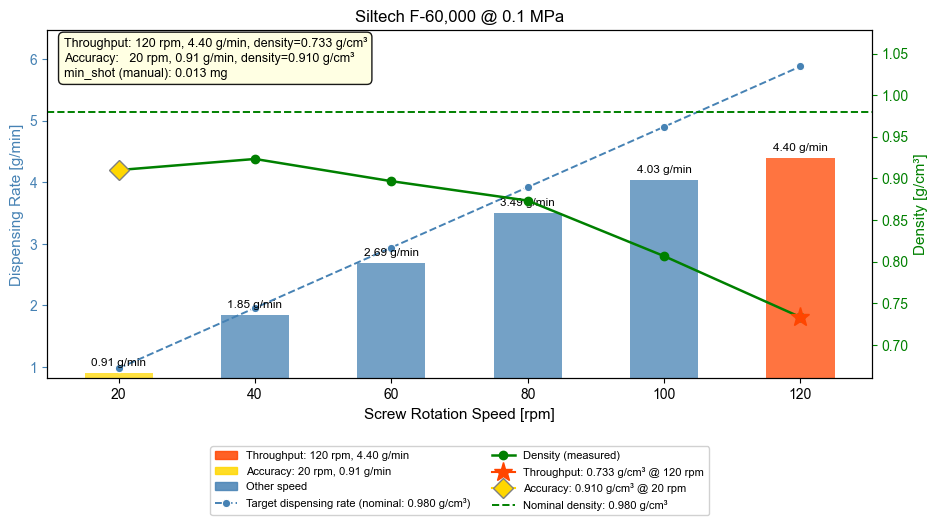

In [74]:

# ---- 2-2. Calibration result plot ----
# Requires: result from cell 2-1 (calibrate_dispenser)
# Nominal density is read from Resource Manager (physical_properties_nominal.density_g_per_cm3).
# If not registered, nominal lines are hidden.
# min_shot (manual) is read from Resource Manager (dispensing_params[device][pressure]["min_shot"]).
# If not registered, "Not measured" is displayed.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from madsci.client.resource_client import ResourceClient

plt.rcParams["font.family"] = "Arial"

# --- Device constant ---
ML_PER_REV = 0.05  # mL per revolution

# --- Calibration result ---
_jr = result.json_result

# --- Resource Manager lookup ---
_RESOURCE_MANAGER_URL = "http://localhost:8003/"
_rc = ResourceClient(resource_server_url=_RESOURCE_MANAGER_URL)
try:
    _mat = _rc.query_resource(resource_name=_jr["material_name"])
    _attrs = _mat.attributes or {}
    _nominal_density = (
        _attrs.get("physical_properties_nominal", {}).get("density_g_per_cm3")
    )
    _device_name_plot = _jr.get("device_name", "high_viscosity_dispenser")
    _pressure_key_plot = f"{_jr['pressure_mpa']}MPa"
    _min_shot_mass_mg = (
        _attrs.get("dispensing_params", {})
        .get(_device_name_plot, {})
        .get(_pressure_key_plot, {})
        .get("min_shot", {})
        .get("measured_mass_mg")
    )
except Exception:
    _nominal_density = None
    _min_shot_mass_mg = None

_min_shot_str = f"{_min_shot_mass_mg} mg" if _min_shot_mass_mg is not None else "Not measured"

# --- Unpack data ---
_results        = _jr["calibration_results"]
_material       = _jr["material_name"]
_pressure       = _jr["pressure_mpa"]
_throughput_speed = _jr["throughput"]["speed_ml_per_min"]
_accuracy_speed   = _jr["accuracy"]["speed_ml_per_min"]

_speeds       = [r["speed_ml_per_min"]  for r in _results]
_densities    = [r["density_g_per_cm3"] for r in _results]
_rpms         = [s / ML_PER_REV         for s in _speeds]
_g_per_min    = [d * s for d, s in zip(_densities, _speeds)]
_throughput_idx = _speeds.index(_throughput_speed)
_accuracy_idx   = _speeds.index(_accuracy_speed)
_throughput_rpm = _rpms[_throughput_idx]
_accuracy_rpm   = _rpms[_accuracy_idx]

_bar_colors = ["steelblue"] * len(_rpms)
_bar_colors[_throughput_idx] = "orangered"
if _accuracy_idx != _throughput_idx:
    _bar_colors[_accuracy_idx] = "gold"

# --- Y-axis range (fit all values with ±10% margin) ---
_left_all = list(_g_per_min)
if _nominal_density is not None:
    _target_g_min = [_nominal_density * rpm * ML_PER_REV for rpm in _rpms]
    _left_all += _target_g_min
_left_min = max(0.0, min(_left_all) * 0.9)
_left_max = max(_left_all) * 1.1

_right_all = list(_densities)
if _nominal_density is not None:
    _right_all.append(_nominal_density)
_right_min = min(_right_all) * 0.9
_right_max = max(_right_all) * 1.1

# --- Figure ---
fig, ax1 = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(bottom=0.30, right=0.95)
ax2 = ax1.twinx()

# Bars: measured dispensing rate [g/min]
_bar_width = (_rpms[-1] - _rpms[0]) / len(_rpms) * 0.6
bars = ax1.bar(_rpms, _g_per_min, width=_bar_width, color=_bar_colors, alpha=0.75)

# Bar labels
_label_offset = (_left_max - _left_min) * 0.015
for bar, val in zip(bars, _g_per_min):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + _label_offset,
        f"{val:.2f} g/min",
        ha="center", va="bottom", fontsize=8.5,
    )

# Target dispensing rate line (steelblue dashed)
if _nominal_density is not None:
    ax1.plot(
        _rpms, _target_g_min,
        color="steelblue", linestyle="--", linewidth=1.4, marker="o", markersize=6,
        markeredgecolor="white", markeredgewidth=0.8,
        label=f"Target dispensing rate (nominal: {_nominal_density:.3f} g/cm³)",
    )

# Measured density line (green, right axis)
ax2.plot(
    _rpms, _densities,
    color="green", marker="o", linewidth=1.8, linestyle="-",
    label="Density (measured)",
)
# Throughput point marker
_throughput_density = _jr["throughput"]["density_g_per_cm3"]
_throughput_g_per_min = _throughput_density * _throughput_speed
ax2.plot(
    _throughput_rpm, _throughput_density,
    marker="*", color="orangered", markersize=14, zorder=6,
    label=f"Throughput: {_throughput_density:.3f} g/cm³ @ {_throughput_rpm:.0f} rpm",
)
# Accuracy point marker
_accuracy_density = _jr["accuracy"]["density_g_per_cm3"]
_accuracy_g_per_min = _accuracy_density * _accuracy_speed
ax2.plot(
    _accuracy_rpm, _accuracy_density,
    marker="D", color="gold", markersize=10, zorder=6, markeredgecolor="gray",
    label=f"Accuracy: {_accuracy_density:.3f} g/cm³ @ {_accuracy_rpm:.0f} rpm",
)
# Nominal density line (green dashed)
if _nominal_density is not None:
    ax2.axhline(
        _nominal_density, color="green", linestyle="--", linewidth=1.4,
        label=f"Nominal density: {_nominal_density:.3f} g/cm³",
    )

# --- Axis styling ---
ax1.set_xlabel("Screw Rotation Speed [rpm]", fontsize=11)
ax1.set_ylabel("Dispensing Rate [g/min]", fontsize=11, color="steelblue")
ax1.tick_params(axis="y", colors="steelblue")
ax1.yaxis.label.set_color("steelblue")

ax2.set_ylabel("Density [g/cm³]", fontsize=11, color="green")
ax2.tick_params(axis="y", colors="green")
ax2.yaxis.label.set_color("green")

ax1.set_ylim(_left_min, _left_max)
ax2.set_ylim(_right_min, _right_max)
ax1.set_xticks(_rpms)

# --- Title ---
ax1.set_title(f"{_material} @ {_pressure} MPa", fontsize=12)

# --- Info box ---
_info = (
    f"Throughput: {_throughput_rpm:.0f} rpm, {_throughput_g_per_min:.2f} g/min, density={_throughput_density:.3f} g/cm³\n"
    f"Accuracy:   {_accuracy_rpm:.0f} rpm, {_accuracy_g_per_min:.2f} g/min, density={_accuracy_density:.3f} g/cm³\n"
    f"min_shot (manual): {_min_shot_str}"
)
ax1.text(
    0.02, 0.98, _info,
    transform=ax1.transAxes,
    fontsize=9, va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.9),
)

# --- Legend ---
_lines1, _labels1 = ax1.get_legend_handles_labels()
_lines2, _labels2 = ax2.get_legend_handles_labels()
_patch_throughput = mpatches.Patch(color="orangered", alpha=0.85,
                                   label=f"Throughput: {_throughput_rpm:.0f} rpm, {_throughput_g_per_min:.2f} g/min")
_patch_accuracy   = mpatches.Patch(color="gold", alpha=0.85,
                                   label=f"Accuracy: {_accuracy_rpm:.0f} rpm, {_accuracy_g_per_min:.2f} g/min")
_patch_rest = mpatches.Patch(color="steelblue", alpha=0.85, label="Other speed")
ax1.legend(
    [_patch_throughput, _patch_accuracy, _patch_rest] + _lines1 + _lines2,
    [_patch_throughput.get_label(), _patch_accuracy.get_label(), _patch_rest.get_label()] + _labels1 + _labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    bbox_transform=ax1.transAxes,
    ncol=2,
    fontsize=8,
    framealpha=0.9,
)

plt.show()


In [21]:

# ---- 3-5. キャリブレーション結果を材料情報に反映 ----
# 上のセルで得た result を Resource Manager の dispensing_params に書き込みます。
# throughput / accuracy の両方と suck_back をデバイスキー配下に保存します。
from madsci.client.resource_client import ResourceClient
from datetime import datetime

RESOURCE_MANAGER_URL = "http://localhost:8003/"
resource_client = ResourceClient(resource_server_url=RESOURCE_MANAGER_URL)

_jr = result.json_result
pressure_mpa = _jr.get("pressure_mpa")
material_name = _jr.get("material_name")
device_name = _jr.get("device_name")
throughput = _jr.get("throughput", {})
accuracy = _jr.get("accuracy", {})

if None in (pressure_mpa, material_name, device_name) or not throughput or not accuracy:
    print("ERROR: キャリブレーション結果が不完全です。上のセルを先に実行してください。")
else:
    PRESSURE_KEY = f"{pressure_mpa}MPa"

    material = resource_client.query_resource(
        resource_name=material_name,
        unique=True,
    )
    attrs = material.attributes or {}
    dispensing_params = attrs.get("dispensing_params", {})
    device_params = dispensing_params.get(device_name, {})

    # throughput / accuracy を圧力キーに保存
    device_params[PRESSURE_KEY] = {
        "throughput": {
            "speed_ml_per_min":  throughput["speed_ml_per_min"],
            "density_g_per_cm3": throughput["density_g_per_cm3"],
        },
        "accuracy": {
            "speed_ml_per_min":  accuracy["speed_ml_per_min"],
            "density_g_per_cm3": accuracy["density_g_per_cm3"],
        },
        "calibrated_at":      datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        "source_type":        "manual",
        "source_datapoint_id": None,
    }

    dispensing_params[device_name] = device_params
    attrs["dispensing_params"] = dispensing_params
    material.attributes = attrs

    updated = resource_client.update_resource(material)
    print(f"更新完了: {updated.resource_name}")
    saved = updated.attributes.get("dispensing_params", {}).get(device_name, {}).get(PRESSURE_KEY, {})
    print(f"  throughput : {saved.get('throughput')}")
    print(f"  accuracy   : {saved.get('accuracy')}")
    print(f"  calibrated_at: {saved.get('calibrated_at')}")


2026-05-13T15:43:57.437010Z [info     ] EventClient initialized        client_name=madsci.client.resource_client event_server='Not configured' log_dir=.madsci\logs log_level=EventLogLevel.INFO madsci_version=0.7.0 platform=Windows-11-10.0.26200-SP0 python_version=3.13.2


更新完了: Siltech F-60,000
  throughput : {'speed_ml_per_min': 6.0, 'density_g_per_cm3': 0.7333333333333334}
  accuracy   : {'speed_ml_per_min': 1.0, 'density_g_per_cm3': 0.9100000000000001}
  calibrated_at: 2026-05-13T11:43:57


---
### 2-4〜2-6. 秤量精度テスト

キャリブレーション結果（accuracy パラメータ）を使って、任意の狙い質量を吐出し、  
実測値との誤差・エラー率・所要時間を評価します。

**前提条件:**
- セル 2-1（`calibrate_dispenser`）と RM 書き込み（セル 2-3）が完了済みであること
- ノード（`high_viscosity_liquid_weighing`）が起動していること


In [75]:
# ---- 3-6-0. dispense アクション 単体確認 ----
# weigh_and_dispense の前に dispense アクション単体が正常動作するかを確認します。
# 結果として actual_mass_g と elapsed_s が返ってくれば OK。
# ノード（high_viscosity_liquid_weighing）が起動していることを確認してから実行してください。
from madsci.client.node.rest_node_client import RestNodeClient
from madsci.common.types.action_types import ActionRequest
import json, time

# --- Edit here ---
DISPENSE_CHECK_MATERIAL  = "Siltech F-60,000"   # Resource Manager に登録済みの材料名
DISPENSE_CHECK_PRESSURE  = 0.1                  # 吐出圧力 [MPa]
DISPENSE_CHECK_TARGET_G  = 0.2                  # 狙い質量 [g]
# -----------------

node_client = RestNodeClient(url="http://localhost:2000/")

print(f"dispense 実行: target={DISPENSE_CHECK_TARGET_G} g, pressure={DISPENSE_CHECK_PRESSURE} MPa")
t_start = time.time()
dispense_result = node_client.send_action(ActionRequest(
    action_name="dispense",
    args={
        "material_name": DISPENSE_CHECK_MATERIAL,
        "target_mass_g": DISPENSE_CHECK_TARGET_G,
        "pressure_mpa":  DISPENSE_CHECK_PRESSURE,
    },
))
elapsed = time.time() - t_start

print(f"ステータス : {dispense_result.status}")
print(f"所要時間   : {elapsed:.1f} sec")
if dispense_result.json_result:
    print(json.dumps(dispense_result.json_result, indent=2, ensure_ascii=False))
if dispense_result.errors:
    for e in dispense_result.errors:
        print(f"ERROR: {e}")


2026-05-14T15:31:22.486226Z [info     ] EventClient initialized        client_name=madsci.client.node.rest_node_client event_server='Not configured' log_dir=.madsci\logs log_level=EventLogLevel.INFO madsci_version=0.7.0 platform=Windows-11-10.0.26200-SP0 python_version=3.13.2


dispense 実行: target=0.2 g, pressure=0.1 MPa
ステータス : ActionStatus.FAILED
所要時間   : 13.0 sec


In [56]:
# ---- 3-6-1. 秤量精度テスト — 実行 ----
# ノードの dispense アクションで各狙い質量を吐出し、実測値を取得します。
from madsci.client.node.rest_node_client import RestNodeClient
from madsci.common.types.action_types import ActionRequest
import json, time

# --- Edit here ---
ACCURACY_TEST_MATERIAL  = "Siltech F-60,000"                        # Resource Manager に登録済みの材料名
ACCURACY_TEST_PRESSURE  = 0.1                                       # 吐出圧力 [MPa]
TARGET_MASSES_G         = [0.010, 0.032, 0.100, 0.316, 1.000]      # 狙い質量 [g]（対数等分）
# -----------------

node_client = RestNodeClient(url="http://localhost:2000/")
accuracy_results = []

for target_g in TARGET_MASSES_G:
    print(f"dispense: target={target_g} g ...", end=" ", flush=True)
    t_start = time.time()
    res = node_client.send_action(ActionRequest(
        action_name="dispense",
        args={
            "material_name": ACCURACY_TEST_MATERIAL,
            "pressure_mpa":  ACCURACY_TEST_PRESSURE,
            "target_mass_g": target_g,
        },
    ))
    elapsed = time.time() - t_start
    if res.json_result:
        actual_g = res.json_result.get("measured_mass_g")
        accuracy_results.append({
            "target_g":  target_g,
            "actual_g":  actual_g,
            "elapsed_s": round(elapsed, 1),
        })
        err = actual_g - target_g
        pct = err / target_g * 100
        print(f"actual={actual_g:.4f} g  ({pct:+.2f}%)  {elapsed:.1f} s")
    else:
        print(f"ERROR: {res.status}  {res.errors}")
        break

print("\nテスト結果:")
print(f"{'#':>2}  {'Target [g]':>10}  {'Actual [g]':>10}  {'Error [g]':>10}  {'Error [%]':>10}  {'Time [s]':>9}")
print("-" * 62)
for i, r in enumerate(accuracy_results):
    err = r["actual_g"] - r["target_g"]
    pct = err / r["target_g"] * 100
    print(f"{i+1:>2}  {r['target_g']:>10.4f}  {r['actual_g']:>10.4f}  {err:>+10.4f}  {pct:>+10.2f}%  {r['elapsed_s']:>9.1f}")


dispense: target=0.01 g ... 

actual=0.0100 g  (+0.00%)  64.5 s
dispense: target=0.032 g ... actual=0.0320 g  (+0.00%)  24.4 s
dispense: target=0.1 g ... actual=0.1020 g  (+2.00%)  24.4 s
dispense: target=0.316 g ... actual=0.3150 g  (-0.32%)  24.4 s
dispense: target=1.0 g ... actual=1.0740 g  (+7.40%)  19.3 s

テスト結果:
 #  Target [g]  Actual [g]   Error [g]   Error [%]   Time [s]
--------------------------------------------------------------
 1      0.0100      0.0100     +0.0000       +0.00%       64.5
 2      0.0320      0.0320     +0.0000       +0.00%       24.4
 3      0.1000      0.1020     +0.0020       +2.00%       24.4
 4      0.3160      0.3150     -0.0010       -0.32%       24.4
 5      1.0000      1.0740     +0.0740       +7.40%       19.3


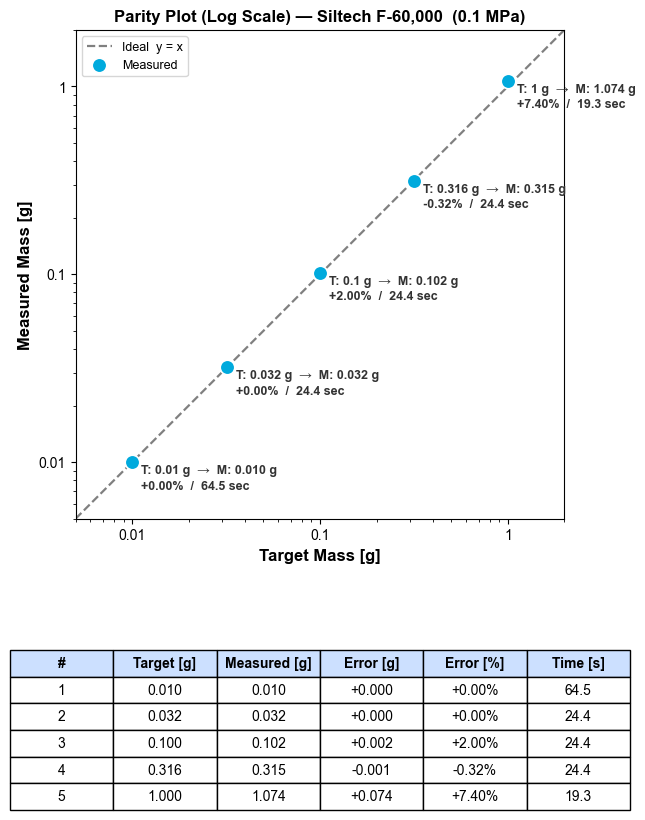

In [58]:
# ---- 3-6-3. 秤量精度テスト — Parity Plot (Log Scale) ----
# Requires: accuracy_results from cell 3-6-1
# ±2% 帯は対数 2 decade で視覚的に表現不可能なため、各点に Target/Measured/ErrorRate/Time を直接注釈する。

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams["font.family"] = "Arial"

targets  = [r["target_g"]  for r in accuracy_results]
actuals  = [r["actual_g"]  for r in accuracy_results]
times    = [r["elapsed_s"] for r in accuracy_results]
errors   = [a - t for a, t in zip(actuals, targets)]
err_pcts = [e / t * 100 for e, t in zip(errors, targets)]

_pt_color = "#00aadd"   # 水色

fig = plt.figure(figsize=(8, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1.0], hspace=0.45)

# ── 上段: Parity Plot（対数軸）──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

_lo_raw = min(targets) * 0.5
_hi_raw = max(targets) * 2.0
_ideal  = np.logspace(np.log10(_lo_raw), np.log10(_hi_raw), 400)

# 理想線 y = x のみ（±2% 帯は視覚的に表現不可能なため省略）
ax1.plot(_ideal, _ideal, color="gray", linestyle="--", linewidth=1.6, label="Ideal  y = x")

# データ点
ax1.scatter(targets, actuals, color=_pt_color, s=110, zorder=5,
            label="Measured", edgecolors="white", linewidth=1.2)

# 各点に Target / Measured / Error Rate / Time を注釈（対数空間でのオフセット）
for t, a, pct, t_s in zip(targets, actuals, err_pcts, times):
    ax1.annotate(
        f"T: {t:g} g  →  M: {a:.3f} g\n{pct:+.2f}%  /  {t_s:.1f} sec",
        xy=(t, a),
        xytext=(t * 1.12, a * 0.97),
        fontsize=9, fontweight="bold", color="#333333",
        va="top", ha="left",
        linespacing=1.4,
        arrowprops=dict(arrowstyle="-", color="lightgray", lw=0.8),
    )

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(_lo_raw, _hi_raw)
ax1.set_ylim(_lo_raw, _hi_raw)

_tick_vals = [0.01, 0.1, 1.0]
ax1.set_xticks(_tick_vals)
ax1.set_yticks(_tick_vals)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))

ax1.set_xlabel("Target Mass [g]",   fontsize=12, fontweight="bold")
ax1.set_ylabel("Measured Mass [g]", fontsize=12, fontweight="bold")
ax1.set_title(
    f"Parity Plot (Log Scale) — {ACCURACY_TEST_MATERIAL}  ({ACCURACY_TEST_PRESSURE} MPa)",
    fontsize=12, fontweight="bold",
)
ax1.legend(fontsize=9, loc="upper left")
ax1.tick_params(labelsize=10)
ax1.set_aspect("equal", adjustable="box")

# ── 下段: テーブル ─────────────────────────────────────────────────────────
ax_tbl = fig.add_subplot(gs[1])
ax_tbl.axis("off")

_col_labels = ["#", "Target [g]", "Measured [g]", "Error [g]", "Error [%]", "Time [s]"]
_rows = []
for i, r in enumerate(accuracy_results):
    err = r["actual_g"] - r["target_g"]
    pct = err / r["target_g"] * 100
    _rows.append([
        str(i + 1),
        f"{r['target_g']:.3f}",
        f"{r['actual_g']:.3f}",
        f"{err:+.3f}",
        f"{pct:+.2f}%",
        f"{r['elapsed_s']:.1f}",
    ])

tbl = ax_tbl.table(cellText=_rows, colLabels=_col_labels, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

for col in range(len(_col_labels)):
    tbl[(0, col)].set_facecolor("#cce0ff")
    tbl[(0, col)].set_text_props(fontweight="bold", fontsize=10)

plt.show()


---
## 3. コマンド確認

デバイスクラス（`HighViscosityDispenserProprietary`）のコマンドを個別に実行して動作を確認します。

| セル | 内容 |
|---|---|
| 3-1 | 連続回転・停止（`start_rotation` / `stop_rotation`） |
| 3-2 | 手動停止（回転開始 / 停止） |
| 3-3 | ステータス確認 |
| 3-4 | 切断 |


In [9]:
# ---- 3-6. start_rotation / stop_rotation（連続回転）----
# 連続的に回転を開始し、手動で stop_rotation() を呼ぶまで回り続ける。
# 流量の目視確認や、長時間連続吐出のテストに使用。
import time

START_SPEED_RPS = 0.5   # 回転速度 [rev/s]（0.5 = 1.5 mL/min）
DIRECTION = +1          # +1: 吐出方向, -1: サックバック方向
RUN_DURATION_S = 3.0    # 連続回転時間 [s]（テスト用）

print(f"start_rotation: {START_SPEED_RPS} rev/s, direction={DIRECTION}")
dispenser_real.start_rotation(speed_rps=START_SPEED_RPS, direction=DIRECTION)
time.sleep(RUN_DURATION_S)
dispenser_real.stop_rotation()
print(f"{RUN_DURATION_S} 秒後に停止完了")

start_rotation: 0.5 rev/s, direction=1
3.0 秒後に停止完了


In [10]:
# ---- 3-7. 手動停止: 回転開始 ----
# このセルを実行するとモーターが回り始めます。
# 止めるときは次のセル（stop）を実行してください。

START_SPEED_RPS = 0.2   # 回転速度 [rev/s]（0.2 = 0.6 mL/min）
DIRECTION = +1          # +1: 吐出方向, -1: サックバック方向

print(f"回転開始: {START_SPEED_RPS} rev/s, direction={DIRECTION}")
print("止めるときは次のセルを実行してください。")
dispenser_real.start_rotation(speed_rps=START_SPEED_RPS, direction=DIRECTION)


回転開始: 0.2 rev/s, direction=1
止めるときは次のセルを実行してください。


In [11]:
# ---- 3-7. 手動停止: 回転停止 ----
# 上のセルで開始した回転を停止します。

dispenser_real.stop_rotation()
print("回転停止完了")


回転停止完了


In [12]:
# ---- 3-7. check_status ----
dispenser_real.check_status()
print(f"status: {dispenser_real.status}")

status: connected


In [13]:
# ---- 3-8. 切断 ----
# モーターを安全停止してシリアル接続を閉じる。
# テスト完了後は必ず実行してください。

dispenser_real.close()
print(f"status: {dispenser_real.status}")

status: disconnected
